In [43]:
from tqdm import tqdm

import pandas as pd
import numpy as np
from scipy import stats

from sklearn.linear_model import LinearRegression
from lightgbm import LGBMRegressor

import econml
from econml.dml import LinearDML

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('fivethirtyeight')

In [44]:
econml.__version__

'0.14.1'

# Is DML Doubly Robust?

According to [Valentin et al. (2025)](https://openreview.net/pdf?id=jt5tghOeK9), **Double Machine Learning** (**DML**) estimators might not be doubly robust when:

1. The treatment model is mmisspecified and 
2. Robison estimator (estimating the total effect of confounders on the outcome) is used to estimate the outcome model

Z-estimator (modeling the direct effect of confounders on the outcome), originally proposed by [Chernozhukov et al. (2018)](https://arxiv.org/abs/1608.00060), solves this problem, similarly to **augemnted DML** proposed by [Valentin et al. (2025)](https://openreview.net/pdf?id=jt5tghOeK9).

In this notebook, we empirically examine whether under the default settings, EconML's `LinearDML` class achieves double robustness under the treatment model misspecification.



This is part of the [CausalPython](https://causalpython.io) series on causality.

<a href="https://causalpython.io"><img src="img/CausalPython.io__flat.png" width=150 align="left"></a>

## Define the DGP

In [46]:
def get_data(n_samples=1000, treatment_effect=3.5):
    X = stats.norm(loc=0, scale=1).rvs(n_samples)
    T = X**2 + stats.norm(loc=0, scale=1).rvs(n_samples)
    Y = treatment_effect*T + X**3 + stats.norm(loc=0, scale=1).rvs(n_samples)
    
    return pd.DataFrame(
        {
            'X': X,
            'T': T,
            'Y': Y
        }
    )

## Run a simulation

In [56]:
N_SIMUL_RUNS = 1000
N_SAMPLES = 1000
TREATMENT_EFFECT = 3.5

results = {
    'misspecified_X_T': [],
    'correct_X_T': []
}

lgbm_params = {
    'n_estimators': 300,
    'num_leaves': 128,
    'learning_rate': 0.05,
    'min_child_samples': 5,
}

for s in tqdm(range(N_SIMUL_RUNS)):
    
    df = get_data(N_SAMPLES, TREATMENT_EFFECT)
    
    # Misspecified treatment model + correct outcome model
    # Treatment is misspecified because the DGP X -> T is non-linear, but we use a linear model -> path not closed correctly
    est_misspecified_treatment = LinearDML(
    model_t=LinearRegression(),
    model_y=LGBMRegressor(**lgbm_params)
    )

    # Correct treatment model + correct outcome model
    est_correct_treatment = LinearDML(
        model_t=LGBMRegressor(**lgbm_params),
        model_y=LGBMRegressor(**lgbm_params)
    )
    
    # Fit both models
    est_misspecified_treatment.fit(
        T=df['T'],
        X=df['X'].values.reshape(-1, 1),
        Y=df['Y']
    )

    est_correct_treatment.fit(
        T=df['T'],
        X=df['X'].values.reshape(-1, 1),
        Y=df['Y']
    )
    
    # Get estimates
    result_misspec = est_misspecified_treatment.effect(X=df['X'].values.reshape(-1, 1), T0=0, T1=1).mean()
    result_correct = est_correct_treatment.effect(X=df['X'].values.reshape(-1, 1), T0=0, T1=1).mean()
    
    # Store the results
    results['misspecified_X_T'].append(result_misspec)
    results['correct_X_T'].append(result_correct)
    

100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [31:30<00:00,  1.89s/it]


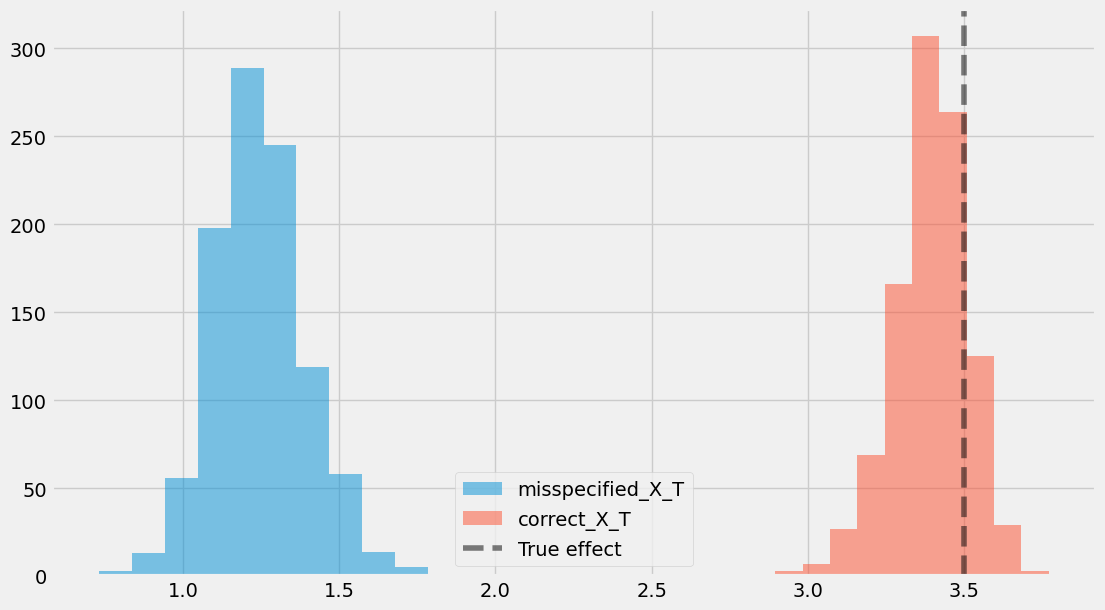

In [59]:
plt.figure(figsize=(12, 7))

for r in results.keys():
    plt.hist(results[r], label=r, alpha=0.5)
    

plt.axvline(TREATMENT_EFFECT, ls='--', color='black', alpha=.5, label='True effect')
plt.legend()
plt.show()

In [58]:
for r in results.keys():
    print(f'{r}: {np.mean(results[r])}')

misspecified_X_T: 1.246303103242907
correct_X_T: 3.3931939839959613


The model with misspecified treatment function is highly biased ($\hat{\tau}_{misspec} \approx 1.25$ vs $\tau = 3.5$)

The model with correctly specified treatment function is much closer to the true value ($\hat{\tau}_{correct} \approx 3.39$ vs $\tau = 3.5$)